### 𝗥𝗮𝗻𝗱𝗼𝗺 𝗦𝗮𝗺𝗽𝗹𝗲 𝗜𝗺𝗽𝘂𝘁𝗮𝘁𝗶𝗼𝗻

Aim: Random sample imputation consists of taking random observation from the dataset and we use this observation to replace the nan values


When should it be used? 
it assumes that the data are missing completely at the random(MCAR)

In [1]:
import pandas as pd 
df=pd.read_csv('titanic.csv',usecols=['Age','Fare','Survived'])
df.head()

,Survived,Age,Fare
0,0,22.0,7.2500
1,1,38.0,71.2833
2,1,26.0,7.9250
3,1,35.0,53.1000
4,0,35.0,8.0500


In [2]:
df.isnull().sum()

Survived      0
Age         177
Fare          0
dtype: int64

In [3]:
df.isnull().mean()

Survived    0.000000
Age         0.198653
Fare        0.000000
dtype: float64

In [32]:
df['Age'].isnull().sum()

np.int64(177)

💡 Important for Data Science interviews

They often ask:

“Why Random Sample Imputation is better than Mean/Median?”

Answer:

1. Preserves variance

2. Maintains data distribution

3. Reduces bias

In [ ]:
##Random Sample Imputation replaces missing values with randomly selected values from the existing non-null data.
df['Age'].dropna().sample(df['Age'].isnull().sum(),random_state=0)

423    28.00
177    50.00
305     0.92
292    36.00
889    26.00
       ...  
539    22.00
267    25.00
352    15.00
99     34.00
689    15.00
Name: Age, Length: 177, dtype: float64

In [36]:
df[df['Age'].isnull()].index

Index([  5,  17,  19,  26,  28,  29,  31,  32,  36,  42,
       ...
       832, 837, 839, 846, 849, 859, 863, 868, 878, 888],
      dtype='int64', length=177)

In [51]:
def impute_nan(df,variable,median):
    df[variable+"_median"]=df[variable].fillna(median)
    df[variable+"_random"]=df[variable]
    ## It will have the random sample to fill the NaN
    random_sample=df[variable].dropna().sample(df[variable].isnull().sum(),random_state=0)
    ##pandas need to have same index in order to merge the dataset
    random_sample.index=df[df[variable].isnull()].index
    df.loc[df[variable].isnull(),variable+'_random']=random_sample

In [52]:
median=df['Age'].median()

In [53]:
median

np.float64(28.0)

In [54]:
impute_nan(df,"Age",median)

In [55]:
df.head()

,Survived,Age,Fare,Age_median,Age_random
0,0,22.0,7.2500,22.0,22.0
1,1,38.0,71.2833,38.0,38.0
2,1,26.0,7.9250,26.0,26.0
3,1,35.0,53.1000,35.0,35.0
4,0,35.0,8.0500,35.0,35.0


In [56]:
import matplotlib.pyplot as  plt
%matplotlib inline

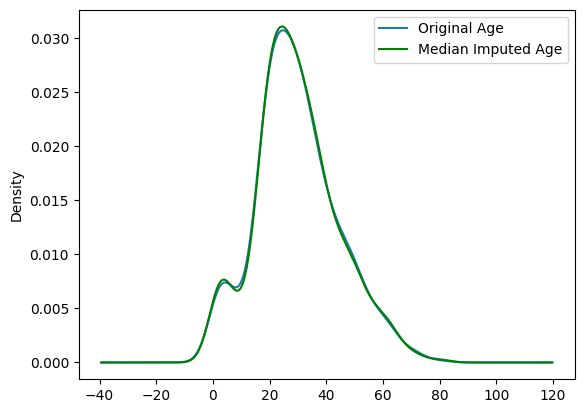

In [62]:

fig = plt.figure()
ax = fig.add_subplot(111)

df['Age'].plot(kind='kde', ax=ax, label='Original Age')
df['Age_random'].plot(kind='kde', ax=ax, color='green', label='Median Imputed Age')

ax.legend(loc='best')

1️⃣ When to use Mean Imputation

Use mean when the data is normally distributed (symmetric).

Example distribution:

        ^
      ^   ^
    ^       ^
  ^           ^
  

Example features:

1. Height

2. Weight

3. Temperature

Reason

Mean works well when no strong outliers exist.

In [ ]:
### df['Age'].fillna(df['Age'].mean())

2️⃣ When to use Median Imputation

Use median when the data is skewed or contains outliers.

Example distribution (right skewed):

Example features:

1. Salary

2. House price

3. Income

Reason

Median is robust to outliers.

In [ ]:
# df['Age'].fillna(df['Age'].median()) 

3️⃣ When to use Random Sample Imputation

Use random sample when you want to preserve the original data distribution.

Example situations:

1. Data has many missing values

2. You want to keep variance

3. Feature is important for the model

Example code:

In [ ]:
# random_sample = df['Age'].dropna().sample(df['Age'].isnull().sum(), random_state=0)

4️⃣ Simple Rule (Very Important)

| Condition                     | Method        |
| ----------------------------- | ------------- |
| Normal distribution           | Mean          |
| Skewed data                   | Median        |
| Want to preserve distribution | Random Sample |


✅ Short interview answer

Mean imputation is used for normally distributed data, median imputation for skewed data with outliers, and random sample imputation when we want to preserve the original distribution of the feature.

Advantage 
1. Easy to implement 
2. There is less distortion in variance

Disadvantage 
1. Every sistuation randomnes won't work

### 𝗖𝗮𝗽𝘁𝘂𝗿𝗶𝗻𝗴 𝗡𝗔𝗡 𝘃𝗮𝗹𝘂𝗲𝘀 𝘄𝗶𝘁𝗵 𝗻𝗲𝘄 𝗳𝗲𝗮𝘁𝘂𝗿𝗲

It works well if the data are not missing completely at ramdom

In [64]:
df=pd.read_csv('titanic.csv',usecols=['Age','Fare','Survived'])
df.head()

,Survived,Age,Fare
0,0,22.0,7.2500
1,1,38.0,71.2833
2,1,26.0,7.9250
3,1,35.0,53.1000
4,0,35.0,8.0500


In [67]:
import numpy as np
df['Age_NAN']=np.where(df['Age'].isnull(),1,0)

In [68]:
df.head()

,Survived,Age,Fare,Age_NAN
0,0,22.0,7.2500,0
1,1,38.0,71.2833,0
2,1,26.0,7.9250,0
3,1,35.0,53.1000,0
4,0,35.0,8.0500,0


Advantages
1. Easy to implement
2. captures the importance of missing values

Disadvantage
1. Creating Additional Feature (Curse of Dimensionality)

## 𝗘𝗻𝗱 𝗼𝗳 𝗗𝗶𝘀𝘁𝗿𝗶𝗯𝘂𝘁𝗶𝗼𝗻 𝗶𝗺𝗽𝘂𝘁𝗮𝘁𝗶𝗼𝗻
It works well if the data are not missing completely at ramdom

In [69]:
df=pd.read_csv('titanic.csv',usecols=['Age','Fare','Survived'])
df.head()

,Survived,Age,Fare
0,0,22.0,7.2500
1,1,38.0,71.2833
2,1,26.0,7.9250
3,1,35.0,53.1000
4,0,35.0,8.0500


<Axes: >

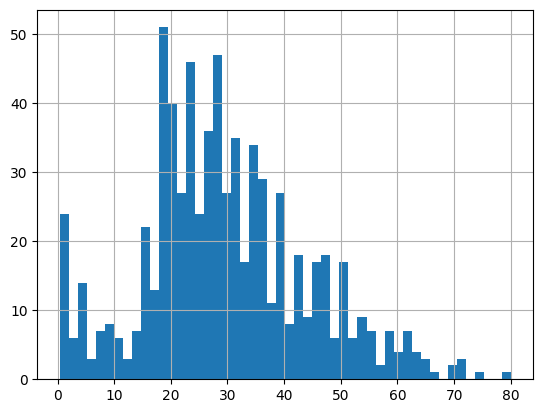

In [71]:
df['Age'].hist(bins=50)

In [72]:
df['Age'].mean()

np.float64(29.69911764705882)

In [86]:
extreme=df.Age.mean()+3*df.Age.std()

<Axes: xlabel='Age'>

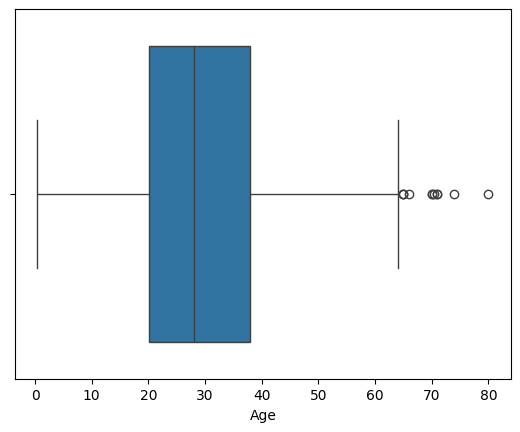

In [87]:
import seaborn as sns 
sns.boxplot(x='Age',data=df)

In [91]:
median=df['Age'].median()
median

np.float64(28.0)

In [95]:
def impute_nan(df, variable, median, extreme):
    
    df[variable+"_end_distribution"] = df[variable].fillna(extreme)
    
    df[variable] = df[variable].fillna(median)

In [96]:
impute_nan(df,'Age',median, extreme)

In [97]:
df.head()

,Survived,Age,Fare,Age_end_distribution
0,0,22.0,7.2500,22.0
1,1,38.0,71.2833,38.0
2,1,26.0,7.9250,26.0
3,1,35.0,53.1000,35.0
4,0,35.0,8.0500,35.0


<Axes: >

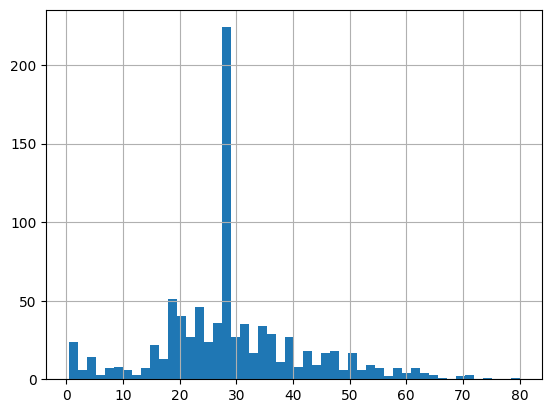

In [98]:
df['Age'].hist(bins=50)

<Axes: >

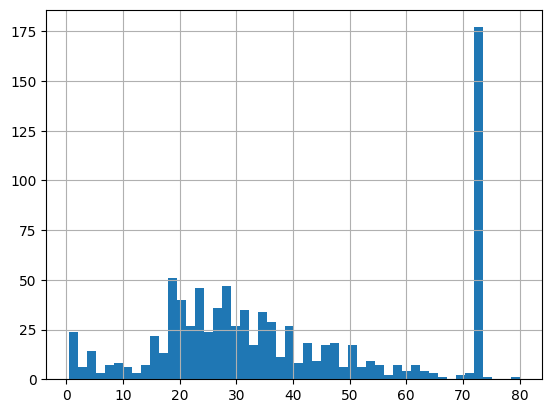

In [107]:
df['Age_end_distribution'].hist(bins=50)

<Axes: xlabel='Age_end_distribution'>

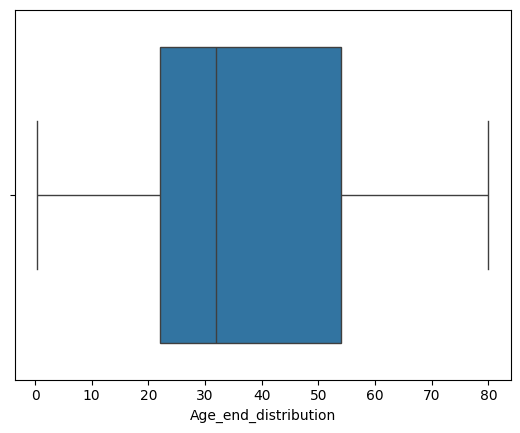

In [103]:
sns.boxplot(x='Age_end_distribution',data=df)

<Axes: xlabel='Age'>

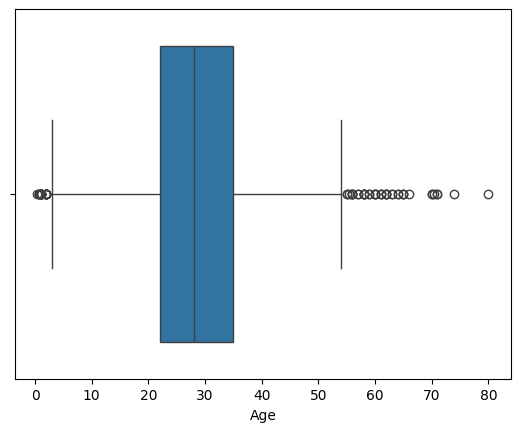

In [104]:
sns.boxplot(x='Age',data=df)

Advantages

1. Easy to implement
2. Captures the importance of missingess if there is one

Disadvantage

1. Distorts the original distribution of the variable
2. if missingess is not important, it may mask the predictive power of the original variable by distorting its distributions
3. if the number of NA is big, it will true outliers in the distribution 
4. If missing values are actually random, extreme imputation may introduce noise instead of useful information.
5. Not suitable for small datasets

| Situation                        | Method              |
| -------------------------------- | ------------------- |
| Normal distribution              | Mean                |
| Skewed distribution              | Median              |
| Preserve distribution            | Random Sample       |
| Missing values carry information | End of Distribution |
